# EDA: Player Positions Analysis

Exploratory Data Analysis of FIFA player positions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load data
df = pd.read_csv('../data/FIFA23/FIFA23_official_data.csv')
print(f"Data loaded: {df.shape[0]} players")

# Clean position data immediately (remove HTML tags like <span...>)
df['Position'] = df['Position'].str.replace(r'<[^>]+>', '', regex=True).str.strip()

print(df[['Name', 'Position', 'Overall', 'Age', 'Club']].head())
# Save cleaned positions data


Data loaded: 17660 players
              Name Position  Overall  Age               Club
0      L. Goretzka      SUB       87   27  FC Bayern München
1  Bruno Fernandes      LCM       86   27  Manchester United
2         M. Acuña       LB       85   30         Sevilla FC
3     K. De Bruyne      RCM       91   31    Manchester City
4       N. Barella      RCM       86   25              Inter


Total unique positions: 29

Top 15 Positions:
Position
SUB    7427
RES    5224
RCB     449
LCB     398
GK      376
ST      346
LB      330
RB      327
RCM     325
LCM     311
RM      284
LM      276
CAM     204
LS      161
LW      149
Name: count, dtype: int64


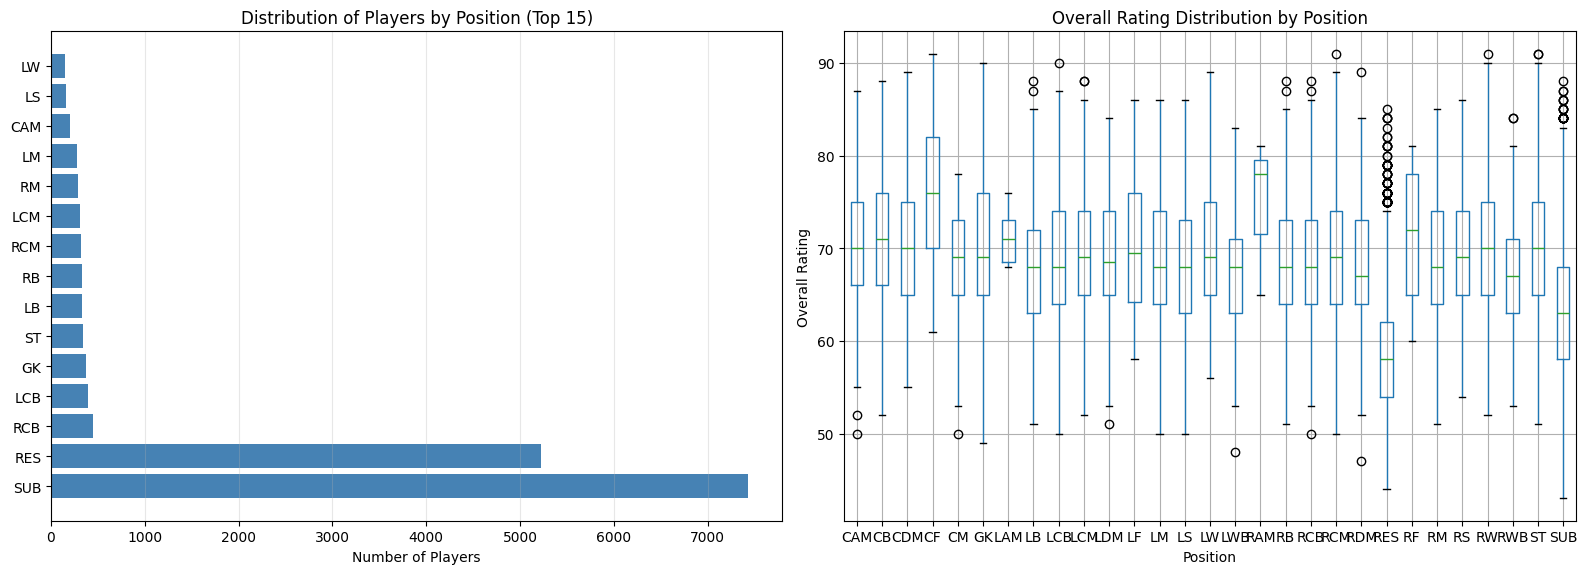

In [2]:
# Parse market value
def parse_currency(val):
    """Convert currency strings like '€115K' to numeric values"""
    if pd.isna(val) or val == '':
        return np.nan
    val = str(val).replace('€', '').strip()
    if 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1_000
    else:
        return float(val) if val else np.nan

df['value_numeric'] = df['Value'].apply(parse_currency)

# Position distribution
position_counts = df['Position'].value_counts().head(15)
print(f"Total unique positions: {df['Position'].nunique()}")
print("\nTop 15 Positions:")
print(position_counts)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
axes[0].barh(position_counts.index, position_counts.values, color='steelblue')
axes[0].set_xlabel('Number of Players')
axes[0].set_title('Distribution of Players by Position (Top 15)')
axes[0].grid(axis='x', alpha=0.3)

# Position vs Overall Rating
df.boxplot(column='Overall', by='Position', ax=axes[1], figsize=(16, 6))
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Overall Rating')
axes[1].set_title('Overall Rating Distribution by Position')
plt.suptitle('')

plt.tight_layout()
plt.show()
# Save parsed values and position counts


In [3]:
# Simplify positions to main category
pos_map = {
    'GK': 'GK',
    'CB':'DEF','LB':'DEF','RB':'DEF','LWB':'DEF','RWB':'DEF',
    'CDM':'MID','CM':'MID','CAM':'MID','LM':'MID','RM':'MID',
    'LW':'ATT','RW':'ATT','ST':'ATT','CF':'ATT','RF':'ATT','LF':'ATT'
}
df['pos_group'] = df['Position'].map(pos_map)

# Average value by specific position
pos_value = (
    df[df['value_numeric'].notna()]
    .groupby('Position')['value_numeric']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
pos_value.columns = ['position', 'avg_value']
pos_value['avg_value_m'] = pos_value['avg_value'] / 1_000_000

fig = px.bar(
    pos_value,
    x='avg_value_m', y='position',
    orientation='h',
    color='avg_value_m',
    color_continuous_scale='Viridis',
    title='Average Market Value by Position (€M)',
    labels={'avg_value_m': 'Avg Value (€M)', 'position': 'Position'},
    template='plotly_dark',
    text='avg_value_m'
)
fig.update_traces(texttemplate='€%{text:.1f}M', textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=500, yaxis={'categoryorder':'total ascending'})
fig.show()
# Save average value by position and final dataset
